In [8]:
%load_ext autoreload
%autoreload 2

import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import pandas as pd

# Ab baaki ka poora code chalega...
# 1. Path routing setup
sys.path.append(os.path.abspath(os.path.join('..')))

# 2. Imports
from src.data_ingestion import DataIngestion
from src.data_transformation import Vocabulary
from src.dataset import ImageCaptionDataset, CapsCollate
from src.model import ImageEncoder, CaptionDecoder

# 3. Setup paths
CAPTION_FILE = "../data/raw/captions.txt"  
IMAGE_DIR = "../data/raw/Images/"     

# 4. Data check and split
ingestion = DataIngestion(caption_file_path=CAPTION_FILE, image_dir=IMAGE_DIR)
df = ingestion.load_data()

train_df, val_df = ingestion.split_data(df, test_size=0.2, random_state=42)

# 5. Build Vocabulary
vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(train_df['caption'].tolist())
vocab_size = len(vocab)
print(f"✨ Success! Total unique vocabulary words: {vocab_size}")

# 6. Data Loader setup
train_dataset = ImageCaptionDataset(train_df, vocab)
pad_idx = vocab.stoi["<PAD>"]

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,       
    shuffle=True,
    num_workers=0,  
    collate_fn=CapsCollate(pad_idx=pad_idx)
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✨ Success! Total unique vocabulary words: 2671


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

# Add root directory imports safely
from src.model import ImageEncoder, CaptionDecoder

# --- THE ABSOLUTE FIX: Define device right here inside this cell ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# -----------------------------------------------------------------

# 1. Hyperparameters setup
EMBED_SIZE = 256
HIDDEN_SIZE = 512
NUM_LAYERS = 1
LEARNING_RATE = 3e-4
EPOCHS = 5

# 2. Ensure vocab variables exist from the previous block
try:
    vocab_size = len(vocab)
    pad_idx = vocab.stoi["<PAD>"]
except NameError:
    # Backup load agar top cell variables break hue hon
    vocab_size = len(train_dataset.vocab)
    pad_idx = train_dataset.vocab.stoi["<PAD>"]

# 3. Build and push models to your active hardware engine
encoder = ImageEncoder(embed_size=EMBED_SIZE).to(device)
decoder = CaptionDecoder(
    embed_size=EMBED_SIZE, 
    hidden_size=HIDDEN_SIZE, 
    vocab_size=vocab_size, 
    num_layers=NUM_LAYERS
).to(device)

# 4. Set Loss and Gradient Optimizer configuration
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
parameters = list(decoder.parameters()) + list(encoder.embed.parameters())
optimizer = optim.Adam(parameters, lr=LEARNING_RATE)

print(f"✨ Success! Neural network brain models successfully built and initialized on {device}.")

c:\Users\nitis\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\nitis\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✨ Success! Neural network brain models successfully built and initialized on cpu.


In [ ]:
import torch
import torch.nn as nn
from src.model import ImageEncoder, CaptionDecoder

# ==========================================
# 1. INITIAL SYSTEM CONFIGURATIONS
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBED_SIZE = 256
HIDDEN_SIZE = 512
VOCAB_SIZE = len(vocab)  # Apne dataset ka actual vocabulary length variable (e.g., len(vocab))

# Models ko initialize karke device par bhejo
encoder = ImageEncoder(embed_size=EMBED_SIZE).to(DEVICE)
decoder = CaptionDecoder(embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE, vocab_size=VOCAB_SIZE).to(DEVICE)

# ==========================================
# 2. LOAD SAVED WEIGHTS (EPOCH 5 CHECKPOINTS)
# ==========================================
print("🔄 Loading existing Epoch 5 checkpoints...")
encoder.load_state_dict(torch.load("../artifacts/encoder_epoch_5.pth", map_location=DEVICE))
decoder.load_state_dict(torch.load("../artifacts/decoder_epoch_5.pth", map_location=DEVICE))
print("✅ Weights successfully restored from artifacts folder!")

# ==========================================
# 3. ENCODER FREEZING & FINE-TUNING SETUP
# ==========================================
# ResNet Base ko freeze rakhenge taaki laptop CPU par load na aaye
for param in encoder.resnet.parameters():
    param.requires_grad = False

# Loss and Optimizer setup (Learning Rate reduced to 0.0003 for smooth convergence)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])
optimizer = torch.optim.Adam(
    list(decoder.parameters()) + list(encoder.embed.parameters()), 
    lr=0.0003
)

# ==========================================
# 4. RESUME LOOP (STARTING FROM EPOCH 6)
# ==========================================
start_epoch = 6
num_epochs = 15  # Isko badha kar 20 ya 25 bhi kar sakte ho training ke dauran

print(f"🔥 Resuming training loop dynamically from Epoch {start_epoch} to {num_epochs}...\n")

for epoch in range(start_epoch, num_epochs + 1):
    encoder.train()
    decoder.train()
    total_loss = 0
    
    # data_loader tumhara wahi rehga jo tumne notebook ke shuruat mein define kiya tha
    for idx, (images, captions) in enumerate(train_loader): 
        images = images.to(DEVICE)
        captions = captions.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Forward Pass execution pipeline
        features = encoder(images)
        outputs = decoder(features, captions)
        
        # Loss calculation (flattening outputs to match vocabulary shape)
        loss = criterion(outputs.view(-1, VOCAB_SIZE), captions.view(-1))
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Every 100 batches progress print karne ke liye
        if idx % 100 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Step [{idx}/{len(train_loader)}], Current Loss: {loss.item():.4f}")
        
    # Average Loss calculation for the whole epoch
    epoch_loss = total_loss / len(train_loader)
    print(f"🏁 Epoch [{epoch}/{num_epochs}] Completed | Avg Loss: {epoch_loss:.4f}\n")
    
    # Tracking metrics by saving weights iteratively (har epoch ke baad checkpoint backup)
    torch.save(encoder.state_dict(), f"../artifacts/encoder_epoch_{epoch}.pth")
    torch.save(decoder.state_dict(), f"../artifacts/decoder_epoch_{epoch}.pth")

🔄 Loading existing Epoch 5 checkpoints...
✅ Weights successfully restored from artifacts folder!
🔥 Resuming training loop dynamically from Epoch 6 to 15...



NameError: name 'data_loader' is not defined

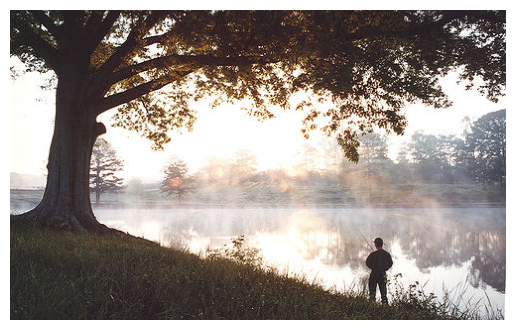


🤖 AI Generated Caption (Epoch 1): startseq a man in a red shirt is sitting on a swing endseq endseq endseq endseq endseq endseq endseq endseq


In [ ]:
# PURANE CODE KO HATA KAR ISS WALE SE REPLACE KARO BHAI

import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from src.model import ImageEncoder, CaptionDecoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

def generate_caption_greedy(image_path, encoder_path, decoder_path, vocab, max_length=20):
    # 1. Image Load & Show
    img = Image.open(image_path).convert("RGB")
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    # 2. Models Setup
    encoder = ImageEncoder(embed_size=256).to(device)
    decoder = CaptionDecoder(embed_size=256, hidden_size=512, vocab_size=len(vocab), num_layers=1).to(device)
    
    encoder.load_state_dict(torch.load(encoder_path, map_location=device))
    decoder.load_state_dict(torch.load(decoder_path, map_location=device))
    
    encoder.eval()
    decoder.eval()
    
    # 3. Greedy Search Generation using forward()
    with torch.no_grad():
        # Feature extract karo image se
        features = encoder(img_tensor).unsqueeze(1) # Shape: (1, 1, embed_size)
        
        # Pehla input <SOS> token hoga
        start_token = vocab.stoi.get("<SOS>", 0)
        inputs = torch.tensor([start_token]).unsqueeze(0).to(device) # Shape: (1, 1)
        
        result_caption = []
        states = None # LSTM states ke liye
        
        for _ in range(max_length):
            # Agar pehla step hai toh image features do, nahi toh sirf text inputs
            if len(result_caption) == 0:
                outputs, states = decoder.lstm(features, states)
            else:
                embeddings = decoder.embed(inputs)
                outputs, states = decoder.lstm(embeddings, states)
            
            outputs = decoder.linear(outputs.squeeze(1)) # Shape: (1, vocab_size)
            predicted_id = outputs.argmax(1).item()
            
            word = vocab.itos[predicted_id]
            if word == "<EOS>":
                break
            if word not in ["<PAD>", "<SOS>"]:
                result_caption.append(word)
                
            # Agle step ka input yahi predicted word banega
            inputs = torch.tensor([predicted_id]).unsqueeze(0).to(device)
            
    return " ".join(result_caption)

# Run Prediction
TEST_IMAGE = "../data/raw/Images/17273391_55cfc7d3d4.jpg"
ENCODER_WEIGHTS = "../artifacts/encoder_epoch_1.pth"
DECODER_WEIGHTS = "../artifacts/decoder_epoch_1.pth"

try:
    predicted_caption = generate_caption_greedy(TEST_IMAGE, ENCODER_WEIGHTS, DECODER_WEIGHTS, vocab)
    print("\n" + "="*40)
    print(f"🤖 AI Generated Caption (Epoch 1): {predicted_caption}")
    print("="*40)
except Exception as e:
    print(f"⚠️ Kuch gadbad hui bhai: {e}")

In [ ]:
from src.model import CaptionDecoder
import inspect

# Dekhte hain decoder ke andar kaun-kaun se functions hain
methods = [func for func in dir(CaptionDecoder) if callable(getattr(CaptionDecoder, func)) and not func.startswith("__")]
print("Bhai, tumhare decoder mein ye functions hain:", methods)

Bhai, tumhare decoder mein ye functions hain: ['_apply', '_call_impl', '_get_backward_hooks', '_get_backward_pre_hooks', '_get_name', '_load_from_state_dict', '_maybe_warn_non_full_backward_hook', '_named_members', '_register_load_state_dict_pre_hook', '_register_state_dict_hook', '_replicate_for_data_parallel', '_save_to_state_dict', '_slow_forward', '_wrapped_call_impl', 'add_module', 'apply', 'bfloat16', 'buffers', 'children', 'compile', 'cpu', 'cuda', 'double', 'eval', 'extra_repr', 'float', 'forward', 'get_buffer', 'get_extra_state', 'get_parameter', 'get_submodule', 'half', 'ipu', 'load_state_dict', 'modules', 'mtia', 'named_buffers', 'named_children', 'named_modules', 'named_parameters', 'parameters', 'register_backward_hook', 'register_buffer', 'register_forward_hook', 'register_forward_pre_hook', 'register_full_backward_hook', 'register_full_backward_pre_hook', 'register_load_state_dict_post_hook', 'register_load_state_dict_pre_hook', 'register_module', 'register_parameter', '